In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Scikit-learn: splitting data
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Scikit-learn: feature selection
from sklearn.feature_selection import SelectKBest, f_classif, RFE

# Scikit-learn: machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-learn: evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# Settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_style('whitegrid')

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [85]:
# Replace the filename below with whatever your file is named
df = pd.read_csv('Telco_Customer_Churn_Dataset  (1) (1).csv')

print(f'Dataset loaded!')
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print()
print('First 5 rows:')
df.head(10)

Dataset loaded!
Rows    : 7043
Columns : 21

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [87]:
print(df['Churn'].value_counts())
print('Churn rate (%):')
print(round(df['Churn'].value_counts(normalize=True) * 100, 2))


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [88]:
print('=== Unique Values Per Column ===')
for col in df.columns:
    print(f'{col:20s} : {df[col].nunique()} unique | example: {df[col].iloc[0]}')


=== Unique Values Per Column ===
customerID           : 7043 unique | example: 7590-VHVEG
gender               : 2 unique | example: Female
SeniorCitizen        : 2 unique | example: 0
Partner              : 2 unique | example: Yes
Dependents           : 2 unique | example: No
tenure               : 73 unique | example: 1
PhoneService         : 2 unique | example: No
MultipleLines        : 3 unique | example: No phone service
InternetService      : 3 unique | example: DSL
OnlineSecurity       : 3 unique | example: No
OnlineBackup         : 3 unique | example: Yes
DeviceProtection     : 3 unique | example: No
TechSupport          : 3 unique | example: No
StreamingTV          : 3 unique | example: No
StreamingMovies      : 3 unique | example: No
Contract             : 3 unique | example: Month-to-month
PaperlessBilling     : 2 unique | example: Yes
PaymentMethod        : 4 unique | example: Electronic check
MonthlyCharges       : 1585 unique | example: 29.85
TotalCharges         : 6531 u

In [101]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print(f'Total missing cells: {df.isnull().sum().sum()}')
df_raw = df.copy()

=== Missing Values ===
Series([], dtype: int64)

Total missing cells: 0


In [90]:
#convert the TotalCharges (from Object to Float)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill TotalCharges missing values with the median
median_val = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_val, inplace=True)
print(f'Missing values after fix: {df.isnull().sum().sum()}')
print(f'Median used for fill: {median_val:.2f}')

Missing values after fix: 0
Median used for fill: 1397.47


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [92]:
df.shape

(7043, 21)

In [93]:
df.drop(columns=['customerID'], inplace=True)
print("CustomerID column dropped")
df.shape

CustomerID column dropped


(7043, 20)

In [95]:
le=LabelEncoder()
bin_col = [col for col in df.columns
           if df[col].dtype == 'object' and df[col].nunique() == 2 and col != 'Churn']
print(bin_col)
for col in bin_col:
  df[col]=le.fit_transform(df[col])
  print(f'{col:20s} -> 0={le.classes_[0]}, 1={le.classes_[1]}')
# Encode the target column: No=0, Yes=1
df['Churn'] = le.fit_transform(df['Churn'])
print()
print('Churn encoded: No=0, Yes=1')


['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
gender               -> 0=Female, 1=Male
Partner              -> 0=No, 1=Yes
Dependents           -> 0=No, 1=Yes
PhoneService         -> 0=No, 1=Yes
PaperlessBilling     -> 0=No, 1=Yes

Churn encoded: No=0, Yes=1


In [99]:
mul_cols=[col for col in df.columns if df[col].dtype== 'object' and df[col].nunique() >2]
print(mul_cols)
df = pd.get_dummies(df, columns=mul_cols, drop_first=True)
print(f'Shape after one-hot encoding: {df.shape}')
print()
print('All columns now:')
print(list(df.columns))
df.shape

[]
Shape after one-hot encoding: (7043, 31)

All columns now:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


(7043, 31)

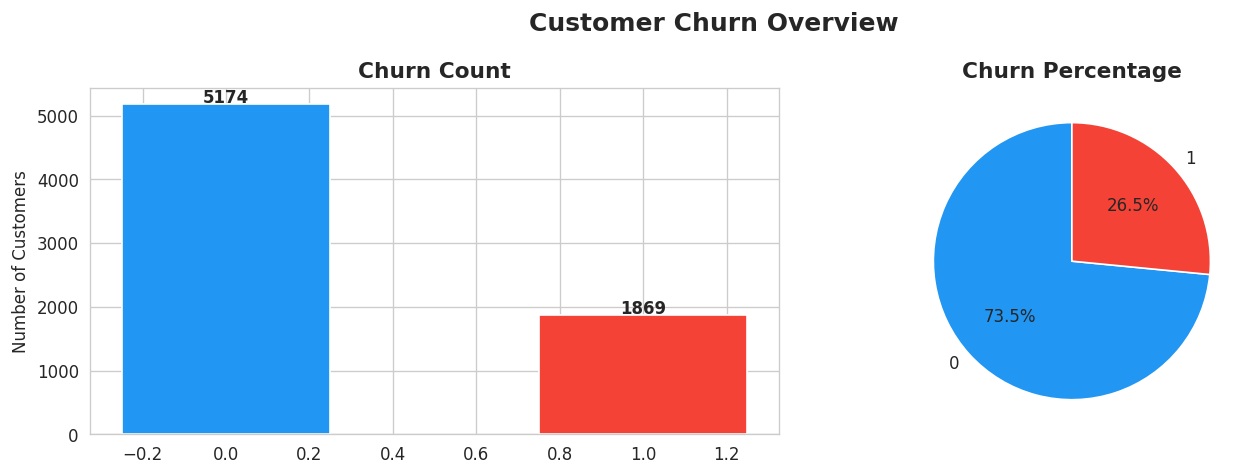

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_counts = df_raw['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(axes[0].patches, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            colors=['#2196F3', '#F44336'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Percentage', fontsize=13, fontweight='bold')

plt.suptitle('Customer Churn Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


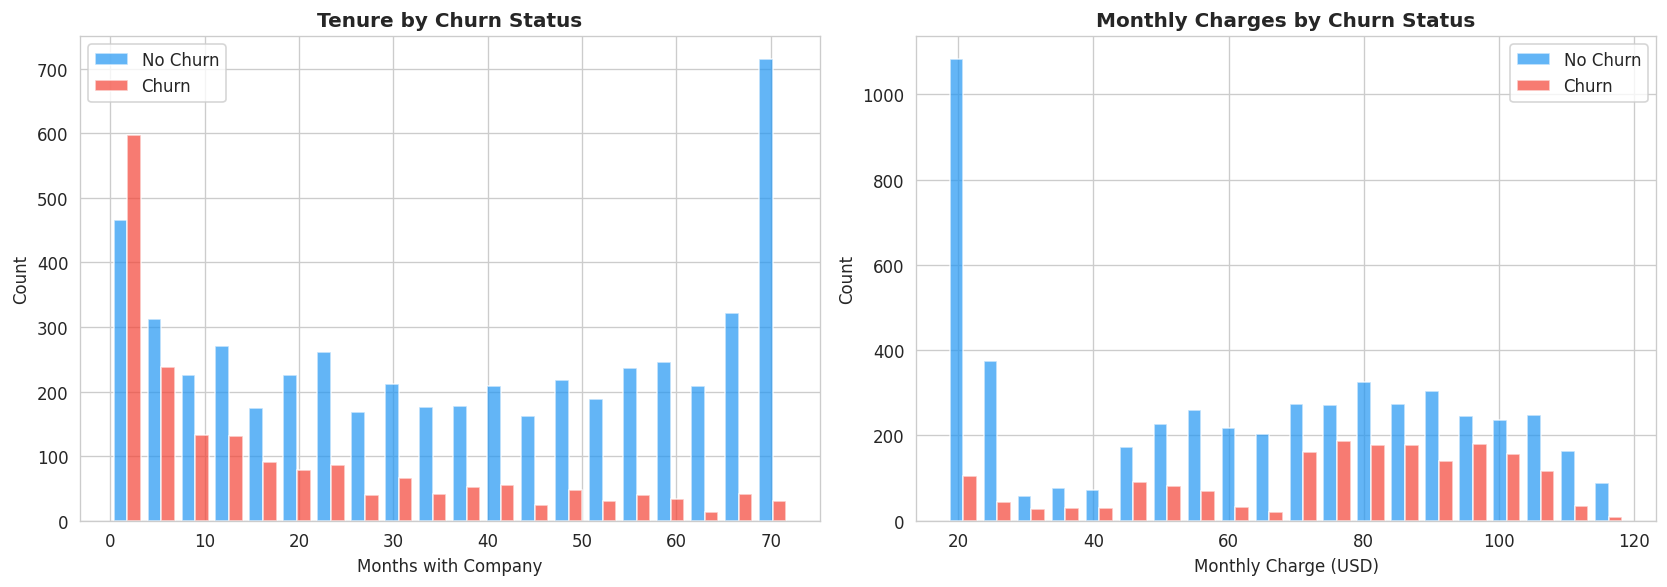

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure histogram
axes[0].hist([df['tenure'][df['Churn']==0],
              df['tenure'][df['Churn']==1]],
             bins=20, color=['#2196F3','#F44336'],
             label=['No Churn','Churn'], alpha=0.7, edgecolor='white')
axes[0].set_title('Tenure by Churn Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Months with Company')
axes[0].set_ylabel('Count')
axes[0].legend()

# Monthly charges histogram
axes[1].hist([df['MonthlyCharges'][df['Churn']==0],
              df['MonthlyCharges'][df['Churn']==1]],
             bins=20, color=['#2196F3','#F44336'],
             label=['No Churn','Churn'], alpha=0.7, edgecolor='white')
axes[1].set_title('Monthly Charges by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Monthly Charge (USD)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()


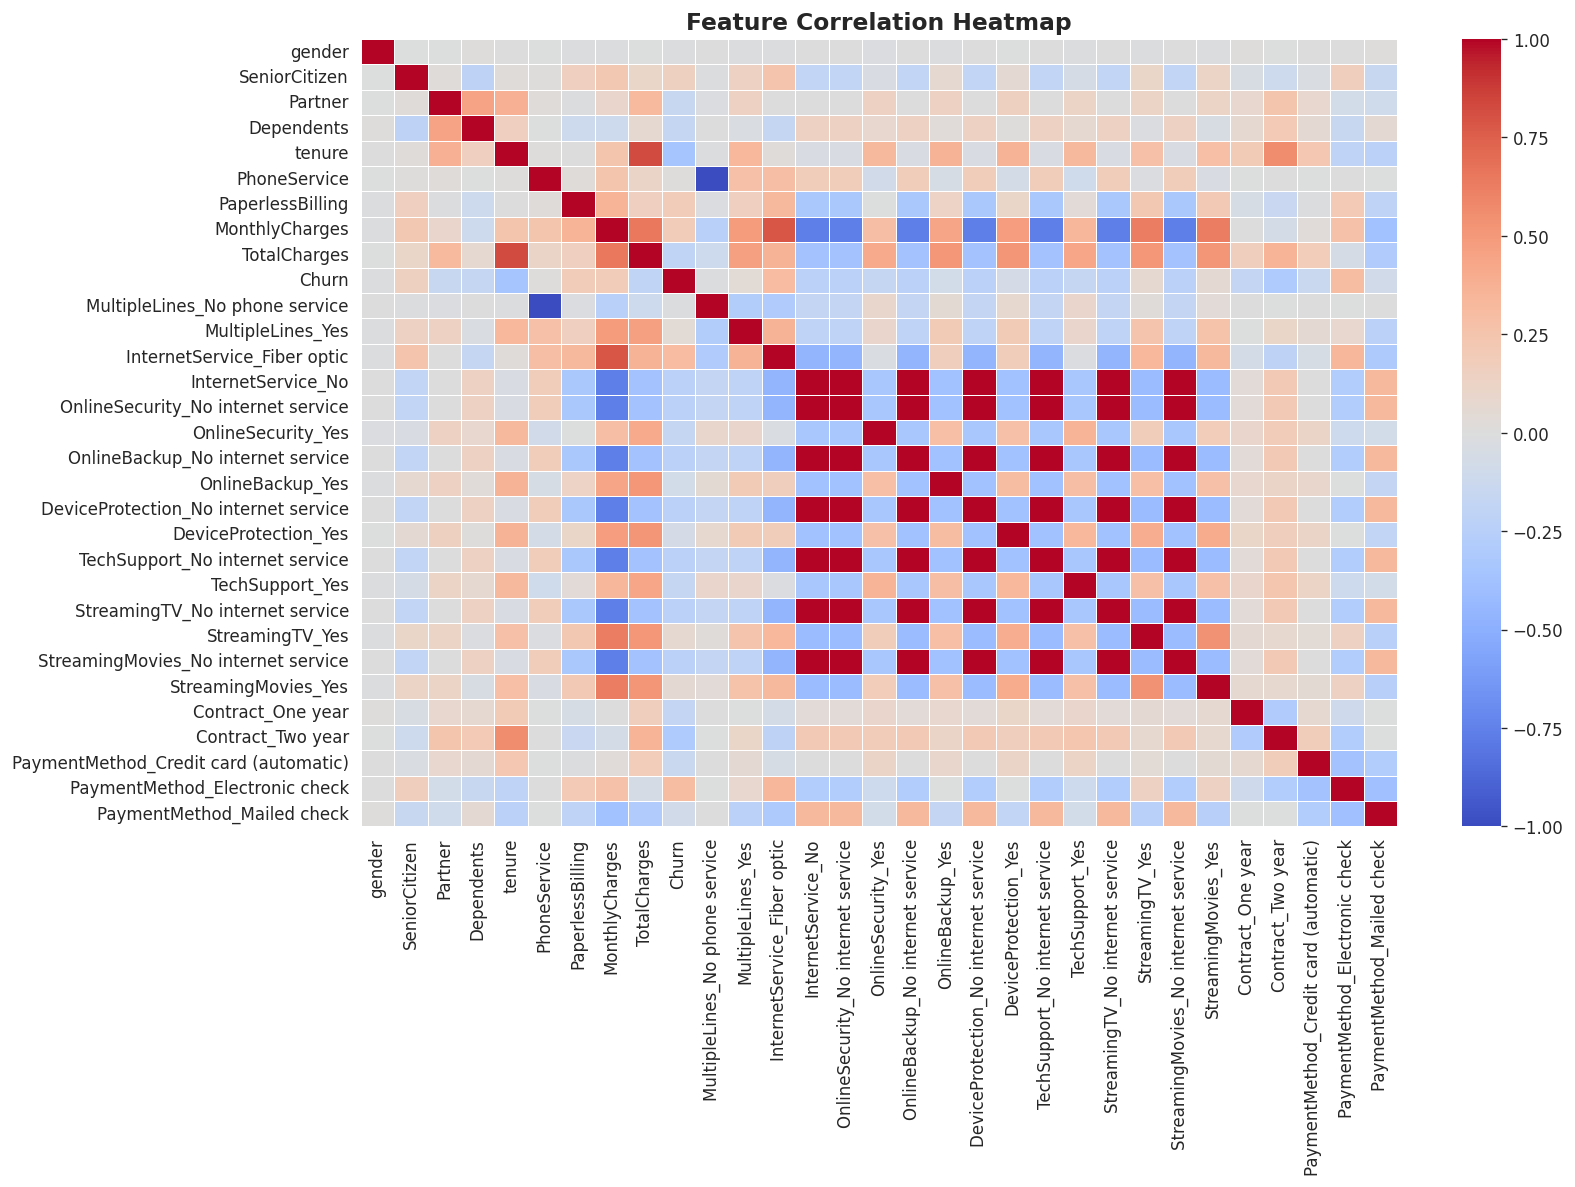

In [104]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()

sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.3,
            fmt='.2f')

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [105]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'Churn rate: {y.mean()*100:.1f}%')


Features (X): (7043, 30)
Target  (y): (7043,)
Churn rate: 26.5%


In [106]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# Build a ranked DataFrame
feature_scores = pd.DataFrame({
    'Feature' : X.columns,
    'F-Score' : selector.scores_,
    'P-Value' : selector.pvalues_
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print('=== Top 15 Features by ANOVA F-Score ===')
print(feature_scores.head(15).to_string(index=False))


=== Top 15 Features by ANOVA F-Score ===
                             Feature    F-Score       P-Value
                              tenure 997.268010 7.999058e-205
         InternetService_Fiber optic 738.046042 1.200784e-154
                   Contract_Two year 707.919254 1.048134e-148
      PaymentMethod_Electronic check 706.195028 2.296890e-148
                  InternetService_No 385.698588  1.200504e-83
  OnlineSecurity_No internet service 385.698588  1.200504e-83
DeviceProtection_No internet service 385.698588  1.200504e-83
     TechSupport_No internet service 385.698588  1.200504e-83
 StreamingMovies_No internet service 385.698588  1.200504e-83
     StreamingTV_No internet service 385.698588  1.200504e-83
    OnlineBackup_No internet service 385.698588  1.200504e-83
                        TotalCharges 290.439831  7.508609e-64
                      MonthlyCharges 273.463704  2.706646e-60
                    PaperlessBilling 268.985218  2.356554e-59
                   Contract_O

In [107]:
from sklearn.feature_selection import RFE

rfe_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rfe = RFE(estimator=rfe_model, n_features_to_select=15)
rfe.fit(X, y)

rfe_features = [col for col, selected in zip(X.columns, rfe.support_) if selected]
print('=== RFE Selected Features (15) ===')
for f in rfe_features:
    print(f'  {f}')


=== RFE Selected Features (15) ===
  Dependents
  PhoneService
  PaperlessBilling
  InternetService_Fiber optic
  InternetService_No
  OnlineSecurity_Yes
  OnlineBackup_Yes
  DeviceProtection_No internet service
  TechSupport_No internet service
  TechSupport_Yes
  StreamingTV_No internet service
  StreamingMovies_No internet service
  Contract_One year
  Contract_Two year
  PaymentMethod_Electronic check


In [108]:
# Combine RFE results + domain knowledge features

domain_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
    'Contract_One year', 'Contract_Two year',
    'InternetService_Fiber optic', 'InternetService_No',
    'OnlineSecurity_Yes', 'TechSupport_Yes',
    'PaymentMethod_Electronic check',
]

# Keep only those that exist in df
domain_features = [f for f in domain_features if f in X.columns]

# Union of both lists
final_features = list(set(rfe_features + domain_features))

print(f'Final feature count: {len(final_features)}')
print(sorted(final_features))

# Create final X
X_selected = X[final_features]


Final feature count: 19
['Contract_One year', 'Contract_Two year', 'Dependents', 'DeviceProtection_No internet service', 'InternetService_Fiber optic', 'InternetService_No', 'MonthlyCharges', 'OnlineBackup_Yes', 'OnlineSecurity_Yes', 'PaperlessBilling', 'PaymentMethod_Electronic check', 'PhoneService', 'SeniorCitizen', 'StreamingMovies_No internet service', 'StreamingTV_No internet service', 'TechSupport_No internet service', 'TechSupport_Yes', 'TotalCharges', 'tenure']


In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y              # preserve the 26.5% churn ratio
)

print('=== Split Summary ===')
print(f'Training set  : {X_train.shape[0]} rows | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Testing  set  : {X_test.shape[0]}  rows | Churn rate: {y_test.mean()*100:.1f}%')

# Scale the features (needed for Logistic Regression)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

print()
print('Scaling done. X_train_sc and X_test_sc are ready.')


=== Split Summary ===
Training set  : 5634 rows | Churn rate: 26.5%
Testing  set  : 1409  rows | Churn rate: 26.5%

Scaling done. X_train_sc and X_test_sc are ready.


In [110]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, min_samples_split=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=RANDOM_STATE
    ),
}

print('Models defined:')
for name in models:
    print(f'  {name}')


Models defined:
  Logistic Regression
  Decision Tree
  Random Forest
  Gradient Boosting


In [111]:
trained_models = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'  Trained: {name}')

print()
print('All models trained!')


  Trained: Logistic Regression
  Trained: Decision Tree
  Trained: Random Forest
  Trained: Gradient Boosting

All models trained!


In [112]:
results = []

for name, model in trained_models.items():
    # Use scaled data for Logistic Regression, raw for trees
    X_te = X_test_sc if name == 'Logistic Regression' else X_test

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results.append({
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'ROC-AUC'   : roc_auc_score(y_test, y_prob),
        '_pred'     : y_pred,
        '_prob'     : y_prob,
    })

# Display as a clean table
metrics_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                           for r in results]).set_index('Model')

print('=== MODEL COMPARISON (as percentages) ===')
print((metrics_df * 100).round(2).to_string())

=== MODEL COMPARISON (as percentages) ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression     80.27      64.91   55.88     60.06    84.30
Decision Tree           73.74      50.33   81.55     62.24    83.13
Random Forest           76.22      53.92   71.66     61.54    83.98
Gradient Boosting       80.70      66.56   54.81     60.12    84.29


In [113]:
for res in results:
    print(f'\n{'='*55}')
    print(f"  {res['Model']}")
    print(f"{'='*55}")
    print(classification_report(y_test, res['_pred'],
                                target_names=['No Churn', 'Churn']))



  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409


  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.82      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg     

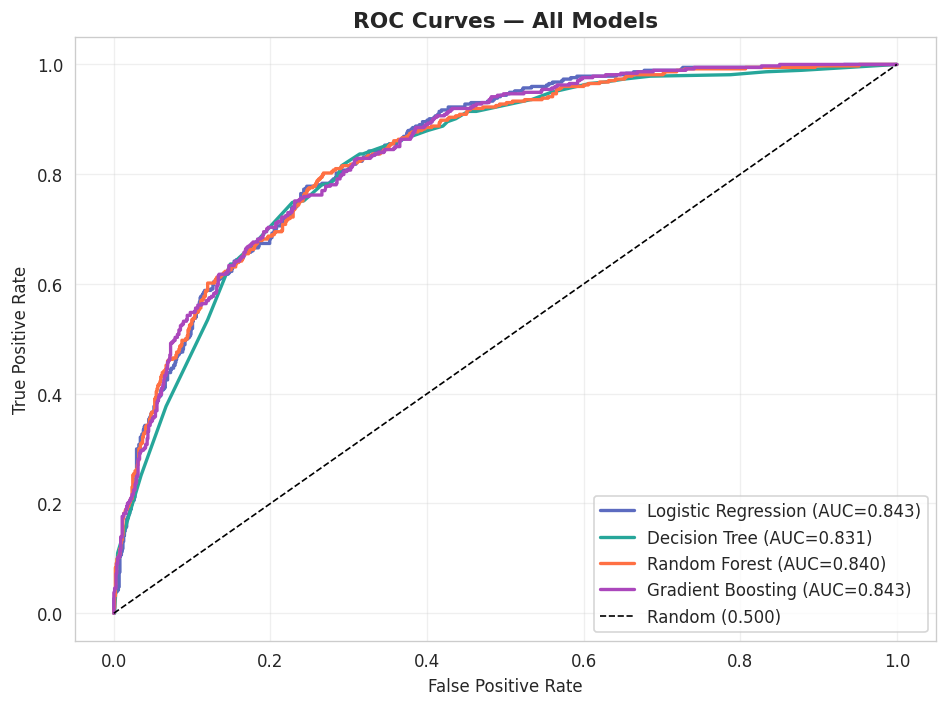

In [114]:
colors = ['#5C6BC0', '#26A69A', '#FF7043', '#AB47BC']

plt.figure(figsize=(8, 6))
for i, res in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, res['_prob'])
    plt.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f"{res['Model']} (AUC={res['ROC-AUC']:.3f})")

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random (0.500)')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


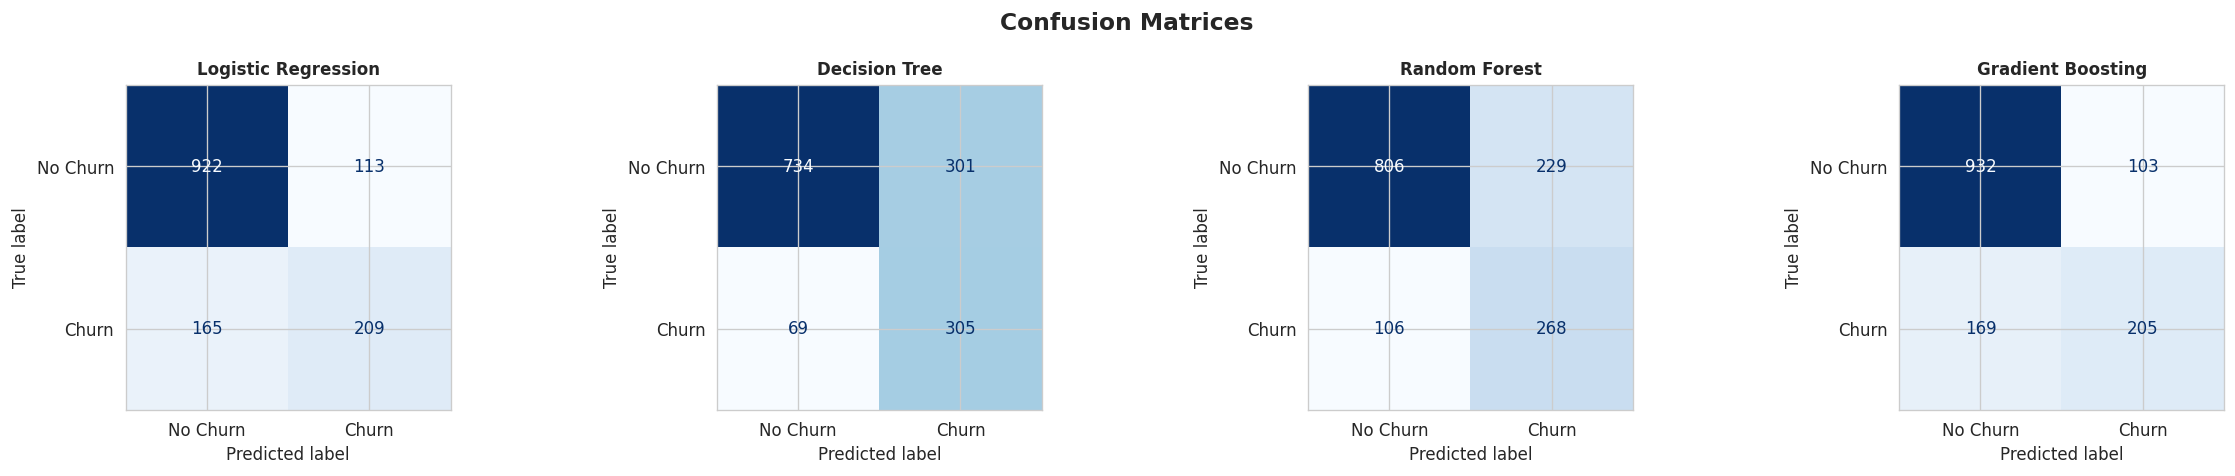

In [115]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, res in zip(axes, results):
    cm = confusion_matrix(y_test, res['_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['Model'], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


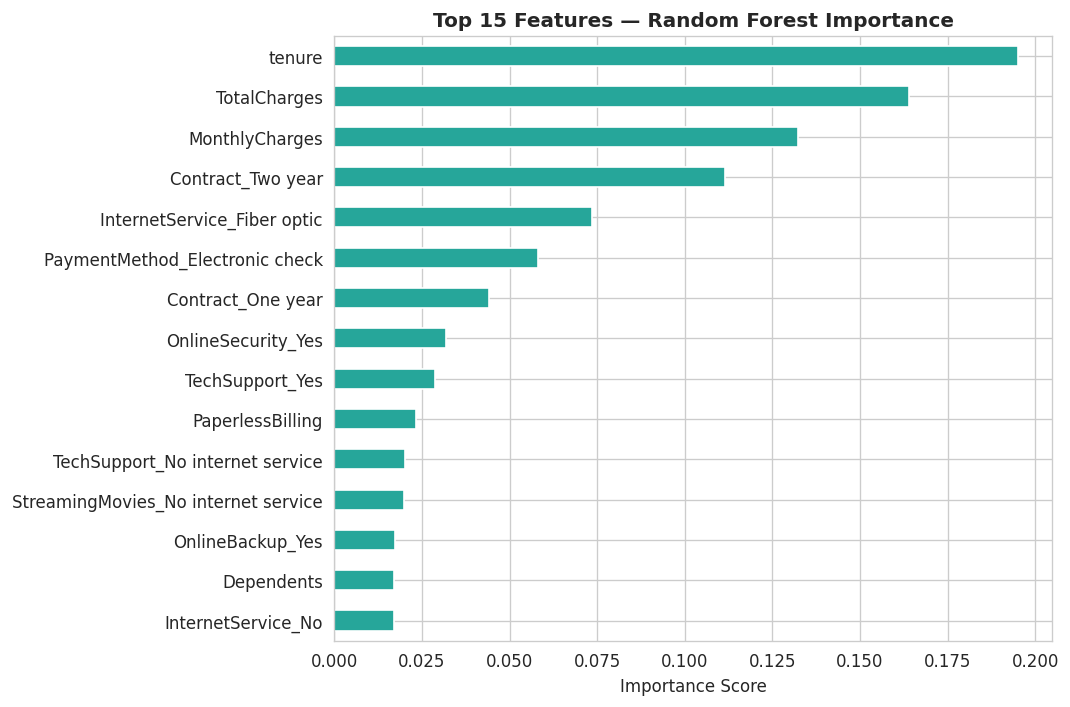

Top 5 most important features:
tenure                         0.195059
TotalCharges                   0.164049
MonthlyCharges                 0.132405
Contract_Two year              0.111537
InternetService_Fiber optic    0.073450


In [116]:
rf = trained_models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_,
                     index=X_train.columns).nlargest(15).sort_values()

plt.figure(figsize=(9, 6))
feat_imp.plot(kind='barh', color='#26A69A', edgecolor='white')
plt.title('Top 15 Features — Random Forest Importance',
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_imp.tail(5).sort_values(ascending=False).to_string())
